<a href="https://colab.research.google.com/github/Boris-Jianing-Mao/PHYS2116/blob/main/GALAH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# install and import packages
# !pip install astroquery astropy -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# the Astropy defaults values, like the sun's location from the galactic center and its movement vectors, have been assumed correct
# These assumptions allow us to calculate the true rotational velocity of the stars
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import Galactocentric

import urllib.request
import os
from google.colab import drive

# hide Astropy UnitsWarnings about non-standard FITS units
import warnings
from astropy.units import UnitsWarning
warnings.filterwarnings('ignore', category=UnitsWarning)

In [ ]:
# link to google drive
# so that I do not have to download the 1GB data every time
drive.mount('/content/drive')
drive_folder = "/content/drive/MyDrive/PHYS2116/Computational Assignment"
os.makedirs(drive_folder, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
main_fits_path = os.path.join(drive_folder, "GALAH_main.fits")
gaia_fits_path = os.path.join(drive_folder, "GALAH_gaia.fits")

url_galah = "https://cloud.datacentral.org.au/teamdata/GALAH/public/GALAH_DR3/GALAH_DR3_main_allstar_v2.fits"
# check if the files are already in my google drive
if not os.path.exists(main_fits_path):
    urllib.request.urlretrieve(url_galah, main_fits_path)
else:
    print("GALAH data already downloaded.")

url_gaia = "https://cloud.datacentral.org.au/teamdata/GALAH/public/GALAH_DR3/GALAH_DR3_VAC_GaiaEDR3_v2.fits"
if not os.path.exists(gaia_fits_path):
    print("File not found on Drive. Downloading now...")
    urllib.request.urlretrieve(url_gaia, gaia_fits_path)
else:
    print("Gaia data already downloaded.")

# convert download data to Pandas DataFrames, and merge them together using the sobject_id
# the GALAH catalog only contains chemistry like metallicity, alpha elements and the Gaia catalog only contains movement like proper motions, parallax
df_galah = Table.read(main_fits_path, format='fits').to_pandas()
df_gaia = Table.read(gaia_fits_path, format='fits').to_pandas()
df = pd.merge(df_galah, df_gaia, on='sobject_id')
# (optional)print all column titles in original and merged data to see how they look like
print(df_galah.columns.tolist())
print(df_gaia.columns.tolist())
print(df.columns.tolist())


GALAH data already downloaded.
Gaia data already downloaded.
['star_id', 'sobject_id', 'dr2_source_id', 'dr3_source_id', 'survey_name', 'field_id', 'flag_repeat', 'wg4_field', 'wg4_pipeline', 'flag_sp', 'teff', 'e_teff', 'irfm_teff', 'irfm_ebv', 'irfm_ebv_ref', 'logg', 'e_logg', 'fe_h', 'e_fe_h', 'flag_fe_h', 'fe_h_atmo', 'vmic', 'vbroad', 'e_vbroad', 'chi2_sp', 'alpha_fe', 'e_alpha_fe', 'nr_alpha_fe', 'flag_alpha_fe', 'flux_A_Fe', 'chi_A_Fe', 'Li_fe', 'e_Li_fe', 'nr_Li_fe', 'flag_Li_fe', 'C_fe', 'e_C_fe', 'nr_C_fe', 'flag_C_fe', 'O_fe', 'e_O_fe', 'nr_O_fe', 'flag_O_fe', 'Na_fe', 'e_Na_fe', 'nr_Na_fe', 'flag_Na_fe', 'Mg_fe', 'e_Mg_fe', 'nr_Mg_fe', 'flag_Mg_fe', 'Al_fe', 'e_Al_fe', 'nr_Al_fe', 'flag_Al_fe', 'Si_fe', 'e_Si_fe', 'nr_Si_fe', 'flag_Si_fe', 'K_fe', 'e_K_fe', 'nr_K_fe', 'flag_K_fe', 'Ca_fe', 'e_Ca_fe', 'nr_Ca_fe', 'flag_Ca_fe', 'Sc_fe', 'e_Sc_fe', 'nr_Sc_fe', 'flag_Sc_fe', 'Sc2_fe', 'e_Sc2_fe', 'nr_Sc2_fe', 'flag_Sc2_fe', 'Ti_fe', 'e_Ti_fe', 'nr_Ti_fe', 'flag_Ti_fe', 'Ti2_fe'

In [ ]:
# some filters to ensure data quality
# flag_sp == 0 for no stellar parameter errors
# flag_fe_h == 0 for no iron abundance errors
# because we will use [Fe/H] to determine the age of stars
# signal to noise ratio > 30
# exclude negative parallex results which is imposible
df_clean = df[(df['flag_sp'] == 0) & (df['flag_fe_h'] == 0) & (df['snr_c3_iraf'] > 30)
& (df['parallax'] > 0)].copy()

# sample target size to 10000 to avoid colab crash(it actually happened)
# use random_state to fix the samples everytime we run the code
df_sample = df_clean.sample(n=10000, random_state=42)

# calculate distance
# distance in parsecs = 1 / parallax angle in arcseconds
# 1 arsecond = 1000 arcmillisecond
# good for nearby stars but limited for further stars
df_sample['distance_pc'] = 1000 / df_sample['parallax']
# we need ra, dec and distance_pc to map the star's position
# we need pmra, pmdec and rv_galah to know how the star is moving
# we need fe_h and alpha_fe to know when and how stars form
cols_to_show = ['sobject_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec', 'rv_galah', 'fe_h', 'alpha_fe', 'distance_pc']
# show 10 rows of data to confirm they look good
display(df_sample[cols_to_show].head(10))

,sobject_id,ra,dec,parallax,pmra,pmdec,rv_galah,fe_h,alpha_fe,distance_pc
274227,160529003401078,212.164822,-21.926167,1.606778,-16.354712,-6.121136,3.651000,-0.212442,0.026561,622.363368
334758,161211003101013,80.604306,-58.532777,1.530713,4.931966,11.808207,23.386000,-0.335356,0.057910,653.290363
230085,160418002601178,139.422225,-21.834438,0.236865,-0.168022,-0.602299,14.924000,-0.247370,0.108978,4221.811737
581860,190212001601254,83.632375,-0.785206,1.032805,-1.602265,-0.158871,-26.827999,-0.514771,-0.033533,968.236981
286298,160811004001006,345.572129,-72.685147,1.985281,4.198763,-7.552797,17.282000,0.103067,-0.059032,503.707097
142909,150606005401112,294.535086,-44.841479,1.389866,-6.528357,7.522470,35.770000,-0.162934,0.015323,719.493750
175810,151110002601391,20.253794,0.695873,1.529225,11.059206,-0.079638,7.233000,-0.494837,0.102009,653.925938
528416,171029002701191,0.398941,-20.794815,2.401735,0.430840,-13.580801,-7.020000,0.028285,0.024121,416.365646
432438,170509005701015,268.711249,-25.353795,3.862455,-27.497549,-36.167074,5.793000,0.021593,0.142510,258.902682
449846,170515006601024,305.087188,9.537551,1.281352,2.334870,-3.452391,-6.252000,-0.131268,0.002151,780.425877


In [ ]:

stars = SkyCoord(ra = df_sample['ra'].values * u.deg, dec = df_sample['dec'].values * u.deg,
    # ra and dec are in degrees
    distance = df_sample['distance_pc'].values * u.pc,
    # distance_pc is in parsecs
    pm_ra_cosdec = df_sample['pmra'].values * u.mas/u.yr, pm_dec = df_sample['pmdec'].values * u.mas/u.yr,
    # pm_ra_cosdec is in milliarcseconds/year
    radial_velocity = df_sample['rv_galah'].values * u.km/u.s)
    # rv_galah is in km/s

# transform from Sun-centered to galactic view
df_sample['l'] = stars.galactic.l.degree #longitude
df_sample['b'] = stars.galactic.b.degree #latitude

# use Galactocentric to see how stars move relative to the galaxy instead of us
galcen = stars.transform_to(Galactocentric())

# change data to cylindrical coordinates to get the rotation curve
galcen.representation_type = 'cylindrical'

# extract the Galactocentric parameters
df_sample['R_kpc'] = galcen.rho.to(u.kpc).value
# 2d radius from galactic center to the star
df_sample['Z_kpc'] = galcen.z.to(u.kpc).value
# height(z axis)

# calculate rotational velocity = angular velocity * radius
df_sample['v_phi'] = (galcen.d_phi * galcen.rho).to(u.km/u.s, u.dimensionless_angles()).value
# radians does not need to converted(otherwise it gives an error!)

# calculate radial velocity and vertical velocity
df_sample['v_R'] = galcen.d_rho.to(u.km/u.s).value
# how fast the star is moving radially(in or out from center)
df_sample['v_Z'] = galcen.d_z.to(u.km/u.s).value
# how fast the star is moving up and down through the disk plane

# let's see what does all these maths produce
cols_to_show = ['sobject_id', 'l', 'b', 'R_kpc', 'Z_kpc', 'v_phi', 'v_R', 'v_Z']
display(df_sample[cols_to_show].head(10))

,sobject_id,l,b,R_kpc,Z_kpc,v_phi,v_R,v_Z
274227,160529003401078,325.676957,37.511300,7.718311,0.398723,-202.199982,7.021996,10.966619
334758,161211003101013,267.094891,-34.393888,8.168003,-0.348160,-222.081468,11.214724,5.440679
230085,160418002601178,250.962424,18.816797,10.151071,1.385843,-205.422958,-97.123912,2.708743
581860,190212001601254,204.619026,-17.415938,8.970842,-0.266849,-257.877220,-47.955235,9.238878
286298,160811004001006,313.532556,-42.122997,7.870176,-0.317707,-218.493039,-20.395978,3.268417
142909,150606005401112,353.940035,-26.695118,7.483900,-0.304063,-260.407203,-61.412317,16.036384
175810,151110002601391,138.465881,-61.280642,8.361253,-0.552078,-227.055017,22.695693,5.324838
528416,171029002701191,59.364453,-76.981803,8.075622,-0.384985,-220.696273,-21.860993,11.271156
432438,170509005701015,4.127561,0.076339,7.863764,0.020484,-190.855840,-22.218399,14.461319
449846,170515006601024,52.113568,-14.860396,7.682360,-0.180536,-234.301093,6.201742,-4.186750


In [ ]:
# calculate the median error directly from raw data columns
median_fe_h_err = df_sample['e_fe_h'].median()
median_alpha_err = df_sample['e_alpha_fe'].median()

print(f"Median [Fe/H] uncertainty: {median_fe_h_err:.3f} dex")
print(f"Median Alpha uncertainty: {median_alpha_err:.3f} dex")

# check the raw radial velocity error from the telescope
median_rv_err = df_sample['e_rv_galah'].median()
print(f"Median radial velocity uncertainty: {median_rv_err:.2f} km/s")

# calculate the fractional distance error for every star using the raw Gaia columns
fractional_error = df_sample['parallax_error'] / df_sample['parallax']

# apply that percentage of error directly to the calculated velocity
df_sample['v_phi_error'] = abs(df_sample['v_phi']) * fractional_error

# find the median error for the entire dataset
V_phi_calculated_error = df_sample['v_phi_error'].median()

print(f"Calculated median V_phi Error: {V_phi_calculated_error:.2f} km/s")

# isolate the thin disk mathematically using only young, iron-rich, alpha-poor stars
thin_disk_mask = (df_sample['fe_h'] > -0.2) & (df_sample['alpha_fe'] < 0.1)
df_thin_disk = df_sample[thin_disk_mask]

# calculate the exact median rotational velocity of this specific population
exact_v_phi = df_thin_disk['v_phi'].median()

# calculate the standard deviation
v_phi_dispersion = df_thin_disk['v_phi'].std()

print(f"Calculated thin disk rotation: {exact_v_phi:.2f} +/- {v_phi_dispersion:.2f} km/s")

# calculate the random velocity v_perp using v_R (radial) and v_Z (vertical)
df_sample['v_perp'] = np.sqrt(df_sample['v_R']**2 + df_sample['v_Z']**2)

# apply the same parallax fractional error for uncertainty estimation
df_sample['v_perp_error'] = df_sample['v_perp'] * (df_sample['parallax_error'] / df_sample['parallax'])

# find the median error to use in the plot
calculated_v_perp_err = df_sample['v_perp_error'].median()

print(f"Calculated random velocity (v_perp) error: {calculated_v_perp_err:.2f} km/s")

# the calculated v_phi error of 2.78 is dominant compare to 0.10 from GALAH data

Median [Fe/H] uncertainty: 0.077 dex
Median Alpha uncertainty: 0.036 dex
Median radial velocity uncertainty: 0.10 km/s
Calculated median V_phi Error: 2.78 km/s
Calculated thin disk rotation: -225.69 +/- 24.38 km/s
Calculated random velocity (v_perp) error: 0.41 km/s


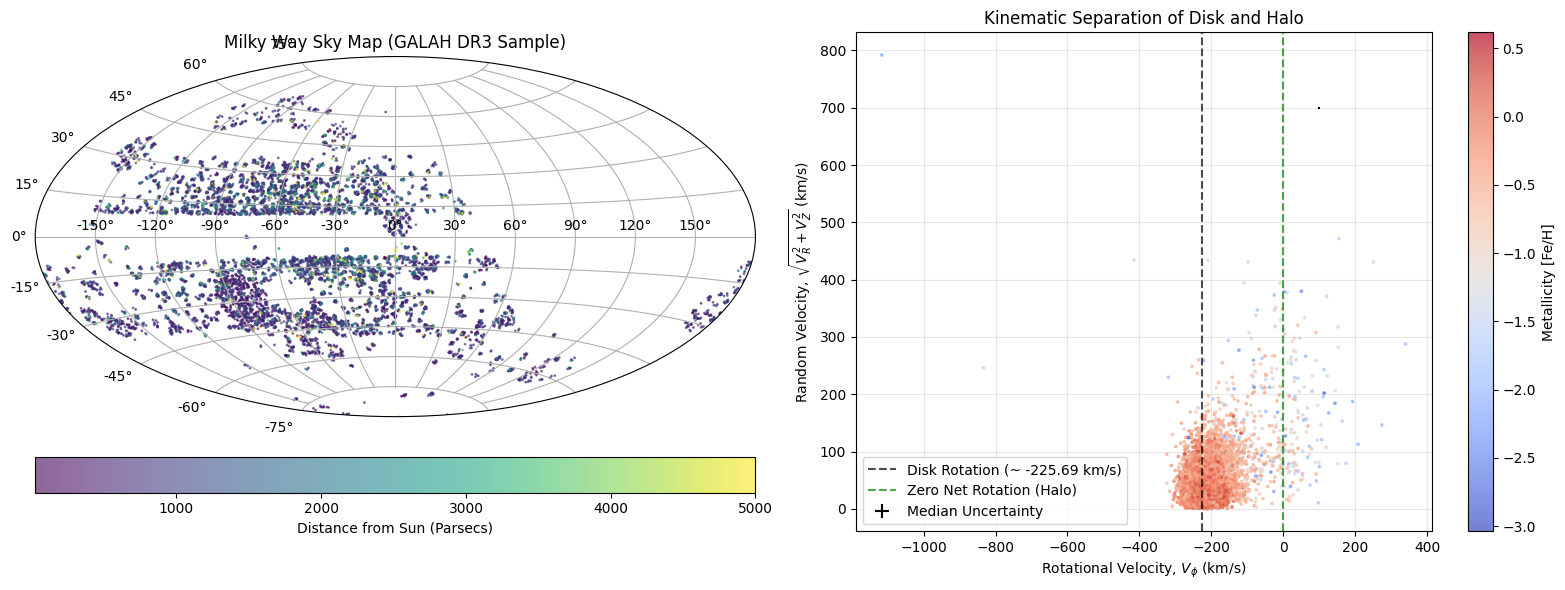

In [ ]:
import matplotlib.pyplot as plt

# shfit coordinates for the Aitoff projection map
l_shifted = df_sample['l'].apply(lambda x: x - 360 if x > 180 else x)
l_rad = np.radians(l_shifted)
b_rad = np.radians(df_sample['b'])


fig = plt.figure(figsize=(16, 6))

# plot 1: position map in galactic coordinates
ax1 = fig.add_subplot(121, projection='aitoff')
# a manual cap of vmax=5000 otherwise color difference won't be visible(to be discussed)
scatter1 = ax1.scatter(l_rad, b_rad, c=df_sample['distance_pc'], cmap='viridis', s=1, alpha=0.6,vmax=5000)

ax1.set_title("Milky Way Sky Map (GALAH DR3 Sample)")
ax1.grid(True)
cbar1 = fig.colorbar(scatter1, ax=ax1, orientation='horizontal', pad=0.08)
cbar1.set_label('Distance from Sun (Parsecs)')

# plot 2: kinematic classification toomre diagram
# v_perp = np.sqrt(df_sample['v_R']**2 + df_sample['v_Z']**2)
# the total velocity calculated by radial and vertical velocity
# this tells how chaotic and wild their path is

ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(df_sample['v_phi'], df_sample['v_perp'], c=df_sample['fe_h'], cmap='coolwarm', s=3, alpha=0.7)
ax2.set_title("Kinematic Separation of Disk and Halo")
ax2.set_xlabel(r'Rotational Velocity, $V_{\phi}$ (km/s)')
ax2.set_ylabel(r'Random Velocity, $\sqrt{V_R^2 + V_Z^2}$ (km/s)')

# the line of 230km/s which represents the rotation of the Milky Way's thin disk
ax2.axvline(exact_v_phi, color='black', linestyle='--', alpha=0.7, label=f'Disk Rotation (~ {exact_v_phi:.2f} km/s)')
# stars here have a higher [Fe/H] and are young
# they have settled into the spinning disk

# error bar
ax2.errorbar(x=99, y=700, xerr=V_phi_calculated_error, yerr=calculated_v_perp_err, color='black', capsize=0, fmt='none', label='Median Uncertainty')
ax2.legend(loc='upper right', fontsize='small')

# the line of 0 km/s which represents the objects that are not rotating with the galaxy(halo)
ax2.axvline(0, color='green', linestyle='--', alpha=0.7, label='Zero Net Rotation (Halo)')
# stars here have a lower [Fe/H] and older
# they never settled into the disk and are still flying around
ax2.legend()
ax2.grid(True, alpha=0.3)

# the color bar for metallicity
cbar2 = fig.colorbar(scatter2, ax=ax2)
cbar2.set_label('Metallicity [Fe/H]')

plt.tight_layout()
plt.show()

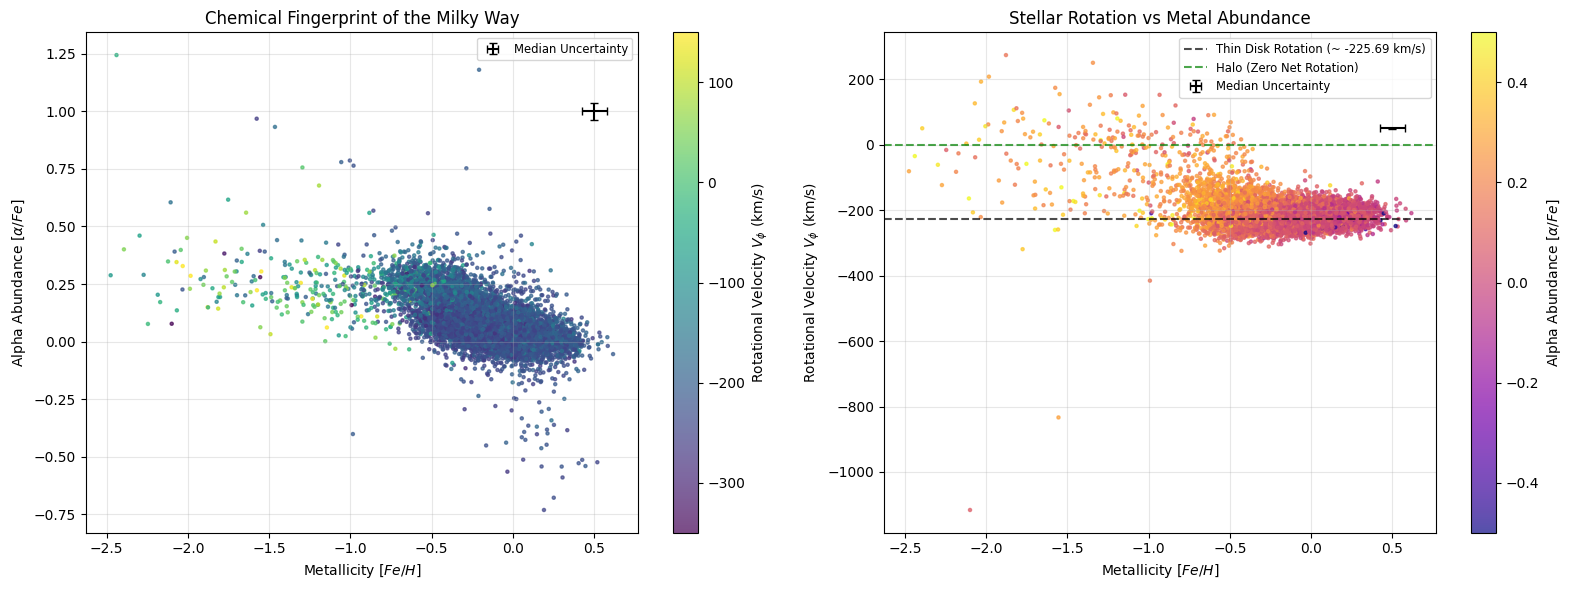

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# plot 1: chemical fingerprint and rotation

# plot [Fe/H] on the x-axis and [alpha/Fe] on the y-axis.
# high alpha abundance (high [alpha/Fe], low Iron) means the star fromed from a gas cloud in early universe
# after the first massive stars exploded and before the binary stars explode to produce iron
# these stars(scattered dots up left) have very low [Fe/H] between -1.0 and -2.5 \
# they are in the halo and are not rotating

# low alpha abundance (low [alpha/Fe], high Iron) means the star fromed later
# after the type 1a supernovae produced sufficient iron into the gas clouds
# these stars(the dense cluster on the right) have a [Fe/H] between roughly -0.5 and +0.5
# they are in the thin disk rotating fast(200-300 km/s)

# the thick disk are stars born in the middle stage
# they have an intermediate amout of Fe/H and slightly higher a/Fe
# they spin a bit slower around 150-180 km/s
# they are on the top left of the dense cluster and are slightly greener(slower)
sc1 = ax1.scatter(df_sample['fe_h'], df_sample['alpha_fe'], c=df_sample['v_phi'], cmap='viridis', s=5, alpha=0.7, vmax=150, vmin = -350)

ax1.set_title('Chemical Fingerprint of the Milky Way')
ax1.set_xlabel(r'Metallicity $[Fe/H]$')
ax1.set_ylabel(r'Alpha Abundance $[\alpha/Fe]$')
ax1.grid(True, alpha=0.3)

# add a colorbar to show rotation speed
cbar1 = fig.colorbar(sc1, ax=ax1)
cbar1.set_label(r'Rotational Velocity $V_{\phi}$ (km/s)')

# add median uncertainties from the filtered sample
ax1.errorbar(x=0.5, y=1.0, xerr=median_fe_h_err, yerr=median_alpha_err, color='black', capsize=3, fmt='none', label='Median Uncertainty')
ax1.legend(loc='upper right', fontsize='small')

# plot 2: rotation vs metallicity colored by alpha abundance

# the x asix of Fe/H acts as a physical timeline
# left to right is ancient to modern
# the leftmost ancient stars are scattered around 0km/s with no spin
# the right side is the young stars that are spinning fast together around 230km/s
sc2 = ax2.scatter(df_sample['fe_h'], df_sample['v_phi'], c=df_sample['alpha_fe'], cmap='plasma', s=5, alpha=0.7, vmin=-0.5, vmax=0.5)

ax2.set_title('Stellar Rotation vs Metal Abundance')
ax2.set_xlabel(r'Metallicity $[Fe/H]$')
ax2.set_ylabel(r'Rotational Velocity $V_{\phi}$ (km/s)')

# add reference lines for the disk and halo
ax2.axhline(exact_v_phi, color='black', linestyle='--', alpha=0.7, label=f'Thin Disk Rotation (~ {exact_v_phi:.2f} km/s)')
ax2.axhline(0, color='green', linestyle='--', alpha=0.7, label='Halo (Zero Net Rotation)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# add a colorbar to show alpha abundance
cbar2 = fig.colorbar(sc2, ax=ax2)
cbar2.set_label(r'Alpha Abundance $[\alpha/Fe]$')

# add kinematic error cross with mathematically derived V_phi uncertainty
ax2.errorbar(x=0.5, y=50, xerr=median_fe_h_err, yerr=V_phi_calculated_error,color='black', capsize=3, fmt='none', label='Median Uncertainty')
ax2.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()